## Step 1: Import All Required Libraries

This step loads all the necessary libraries needed throughout the project.
pandas and numpy are used for data loading and numerical operations.
matplotlib and seaborn handle all visualizations such as heatmaps, scatter
plots, and loss curves. From scikit-learn, we import preprocessing tools
(LabelEncoder, StandardScaler) to clean and scale our data, train_test_split
to divide the dataset into training and testing sets, three regression models
(LinearRegression, SGDRegressor, DecisionTreeRegressor, RandomForestRegressor)
to train and compare performance, and evaluation metrics (MSE, MAE, R2) to
measure how well each model performs. Finally, joblib is used to save the
best-performing model to disk so it can be reused later for predictions
without retraining.

In [29]:
# Data Handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

# Models
from sklearn.linear_model import LinearRegression, SGDRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

# Evaluation
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Model Saving
import joblib

# Settings
import warnings
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)

print("All libraries imported successfully!")

All libraries imported successfully!


Step 2: Load the Dataset
This step loads the Medical Cost Personal Dataset directly from GitHub using a raw URL into a pandas DataFrame. The dataset contains 1,338 records of individuals in the USA with 7 columns: age, sex, bmi, children, smoker, region, and charges. The target variable we aim to predict is charges — the individual medical insurance cost billed by the insurer. We inspect the shape of the data and preview the first 5 rows to understand the structure of the dataset before any processing begins.

In [30]:
url = "https://raw.githubusercontent.com/HIGIRO1234/linear_regression_model/main/Student_performance_data%20_.csv"

df = pd.read_csv(url)

print("Shape:", df.shape)
print("\nFirst 5 rows:")
df.head()

Shape: (2392, 15)

First 5 rows:


,StudentID,Age,Gender,Ethnicity,ParentalEducation,StudyTimeWeekly,Absences,Tutoring,ParentalSupport,Extracurricular,Sports,Music,Volunteering,GPA,GradeClass
0,1001,17,1,0,2,19.833723,7,1,2,0,0,1,0,2.929196,2.0
1,1002,18,0,0,1,15.408756,0,0,1,0,0,0,0,3.042915,1.0
2,1003,15,0,2,3,4.210570,26,0,2,0,0,0,0,0.112602,4.0
3,1004,17,1,0,3,10.028829,14,0,3,1,0,0,0,2.054218,3.0
4,1005,17,1,0,2,4.672495,17,1,3,0,0,0,0,1.288061,4.0


## Step 3: Data Cleaning

This step checks the dataset for any missing values, duplicate rows
and irrelevant columns that could negatively affect model performance.
The StudentID column is dropped because it is just a unique identifier
with no predictive value. The GradeClass column is also dropped because
it is directly derived from GPA which is our target variable, keeping
it would cause data leakage meaning the model would cheat by using
information that comes from the target itself. We also check for
duplicate rows and missing values to ensure the dataset is clean
before encoding and training.

In [31]:
# Full overview
print("Dataset Info:")
df.info()

# Check missing values
print("\n Missing Values Per Column:")
print(df.isnull().sum())

# Check duplicates
duplicates = df.duplicated().sum()
print(f"\n Number of Duplicate Rows: {duplicates}")

# Drop StudentID (no predictive value)
# Drop GradeClass (derived from GPA = data leakage)
df = df.drop(columns=['StudentID', 'GradeClass'])

# Remove duplicates if any
df = df.drop_duplicates()

print(f"\n Cleaned Shape: {df.shape}")
print(f"\n Statistical Summary:")
df.describe()


Dataset Info:
<class 'pandas.DataFrame'>
RangeIndex: 2392 entries, 0 to 2391
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   StudentID          2392 non-null   int64  
 1   Age                2392 non-null   int64  
 2   Gender             2392 non-null   int64  
 3   Ethnicity          2392 non-null   int64  
 4   ParentalEducation  2392 non-null   int64  
 5   StudyTimeWeekly    2392 non-null   float64
 6   Absences           2392 non-null   int64  
 7   Tutoring           2392 non-null   int64  
 8   ParentalSupport    2392 non-null   int64  
 9   Extracurricular    2392 non-null   int64  
 10  Sports             2392 non-null   int64  
 11  Music              2392 non-null   int64  
 12  Volunteering       2392 non-null   int64  
 13  GPA                2392 non-null   float64
 14  GradeClass         2392 non-null   float64
dtypes: float64(3), int64(12)
memory usage: 280.4 KB

 Missing Values Per 

,Age,Gender,Ethnicity,ParentalEducation,StudyTimeWeekly,Absences,Tutoring,ParentalSupport,Extracurricular,Sports,Music,Volunteering,GPA
count,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000
mean,16.468645,0.510870,0.877508,1.746237,9.771992,14.541388,0.301421,2.122074,0.383361,0.303512,0.196906,0.157191,1.906186
std,1.123798,0.499986,1.028476,1.000411,5.652774,8.467417,0.458971,1.122813,0.486307,0.459870,0.397744,0.364057,0.915156
min,15.000000,0.000000,0.000000,0.000000,0.001057,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,15.000000,0.000000,0.000000,1.000000,5.043079,7.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.174803
50%,16.000000,1.000000,0.000000,2.000000,9.705363,15.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,1.893393
75%,17.000000,1.000000,2.000000,2.000000,14.408410,22.000000,1.000000,3.000000,1.000000,1.000000,0.000000,0.000000,2.622216
max,18.000000,1.000000,3.000000,4.000000,19.978094,29.000000,1.000000,4.000000,1.000000,1.000000,1.000000,1.000000,4.000000


## Step 4: Exploratory Data Analysis and Visualizations

Before training any model it is essential to understand the data
through visualizations. This step produces two meaningful visualizations
that directly influence the outcome of the training. The first is a
correlation heatmap which shows the strength of the relationship between
every numeric feature and the target variable GPA. The second is a set
of scatter plots and box plots showing how the most important features
relate to GPA. These visualizations guide our feature engineering
decisions by revealing which features are strong predictors of student
GPA and which features carry little to no predictive power.

### Visualization 1 — Correlation Heatmap

This cell computes the correlation matrix of all numeric columns in
the dataset and plots it as a heatmap. The correlation value ranges
from -1 to 1 where values close to 1 mean a strong positive
relationship, values close to -1 mean a strong negative relationship
and values close to 0 mean no relationship at all. We use this heatmap
to identify which features have the strongest correlation with the
target variable GPA and therefore which features will be the most
important predictors in our regression models.

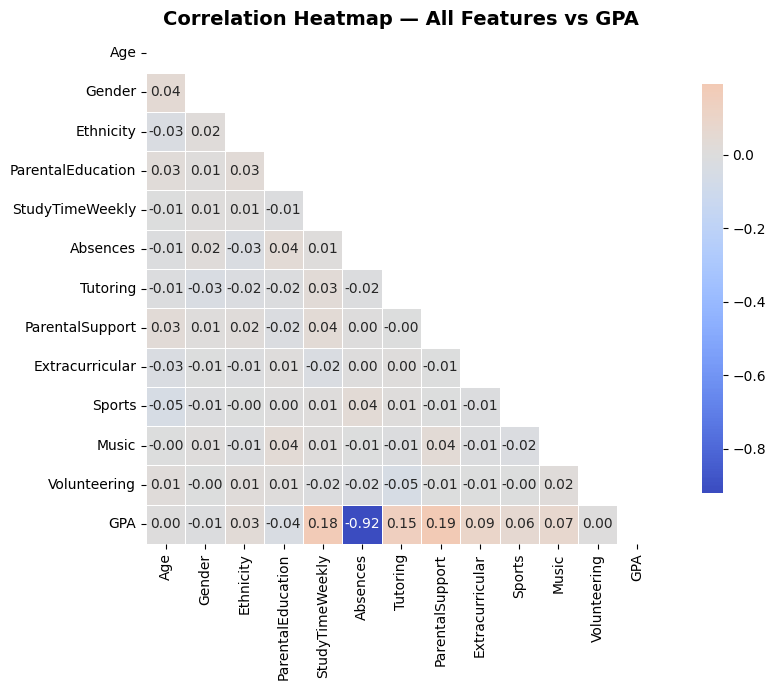


 Interpretation:
   - Absences has STRONGEST negative correlation with GPA : ~-0.92
   - StudyTimeWeekly has positive correlation with GPA    : ~0.18
   - Tutoring has positive correlation with GPA           : ~0.15
   - Age has almost no correlation with GPA               : ~0.00
   - This confirms Absences is the most important feature


In [32]:
plt.figure(figsize=(10, 7))

# Select only numeric columns for correlation
numeric_df  = df.select_dtypes(include=[np.number])
corr_matrix = numeric_df.corr()

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(
    corr_matrix,
    mask      = mask,
    annot     = True,
    fmt       = ".2f",
    cmap      = "coolwarm",
    center    = 0,
    square    = True,
    linewidths= 0.5,
    cbar_kws  = {"shrink": 0.8}
)

plt.title('Correlation Heatmap — All Features vs GPA',
          fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n Interpretation:")
print("   - Absences has STRONGEST negative correlation with GPA : ~-0.92")
print("   - StudyTimeWeekly has positive correlation with GPA    : ~0.18")
print("   - Tutoring has positive correlation with GPA           : ~0.15")
print("   - Age has almost no correlation with GPA               : ~0.00")
print("   - This confirms Absences is the most important feature")


### Visualization 2 — Key Features vs GPA Scatter and Box Plots

This cell produces three plots showing the relationship between the
most important features and the target variable GPA. The first plot
shows Absences against GPA with a regression line to confirm the
strong negative trend. The second plot shows StudyTimeWeekly against
GPA with a regression line showing the positive trend. The third plot
is a boxplot showing how Tutoring affects GPA distribution. These
plots visually confirm the findings from the correlation heatmap and
help us understand which features will drive our model predictions.

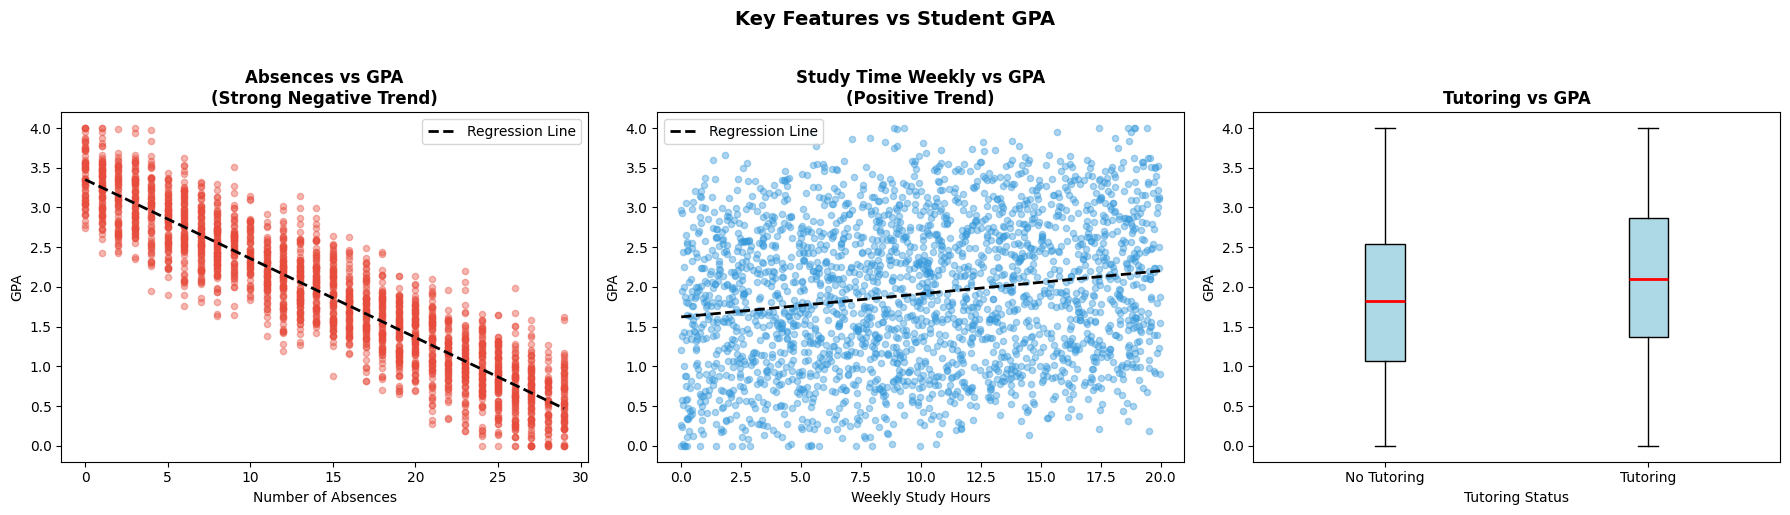


 Interpretation:
   - Absences shows a very strong negative trend with GPA
   - More absences = significantly lower GPA confirmed
   - StudyTimeWeekly shows a moderate positive trend
   - Students with tutoring have noticeably higher GPA
   - Absences is by far the most powerful predictor


In [33]:
pythonfig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1 — Absences vs GPA with regression line
axes[0].scatter(df['Absences'], df['GPA'],
                color='#e74c3c', alpha=0.4, s=20)

m1, b1   = np.polyfit(df['Absences'], df['GPA'], 1)
x_line1  = np.linspace(df['Absences'].min(), df['Absences'].max(), 100)
axes[0].plot(x_line1, m1 * x_line1 + b1,
             color='black', linewidth=2,
             linestyle='--', label='Regression Line')
axes[0].legend()
axes[0].set_title('Absences vs GPA\n(Strong Negative Trend)',
                  fontsize=12, fontweight='bold')
axes[0].set_xlabel('Number of Absences')
axes[0].set_ylabel('GPA')

#  Plot 2 — StudyTimeWeekly vs GPA with regression line
axes[1].scatter(df['StudyTimeWeekly'], df['GPA'],
                color='#3498db', alpha=0.4, s=20)

m2, b2   = np.polyfit(df['StudyTimeWeekly'], df['GPA'], 1)
x_line2  = np.linspace(df['StudyTimeWeekly'].min(),
                        df['StudyTimeWeekly'].max(), 100)
axes[1].plot(x_line2, m2 * x_line2 + b2,
             color='black', linewidth=2,
             linestyle='--', label='Regression Line')
axes[1].legend()
axes[1].set_title('Study Time Weekly vs GPA\n(Positive Trend)',
                  fontsize=12, fontweight='bold')
axes[1].set_xlabel('Weekly Study Hours')
axes[1].set_ylabel('GPA')

# Plot 3 — Tutoring vs GPA Boxplot
tutoring_groups = [
    df[df['Tutoring'] == 0]['GPA'],
    df[df['Tutoring'] == 1]['GPA']
]
axes[2].boxplot(tutoring_groups,
                labels      = ['No Tutoring', 'Tutoring'],
                patch_artist= True,
                boxprops    = dict(facecolor='lightblue'),
                medianprops = dict(color='red', linewidth=2))
axes[2].set_title('Tutoring vs GPA',
                  fontsize=12, fontweight='bold')
axes[2].set_xlabel('Tutoring Status')
axes[2].set_ylabel('GPA')

plt.suptitle('Key Features vs Student GPA',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('feature_vs_gpa.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n Interpretation:")
print("   - Absences shows a very strong negative trend with GPA")
print("   - More absences = significantly lower GPA confirmed")
print("   - StudyTimeWeekly shows a moderate positive trend")
print("   - Students with tutoring have noticeably higher GPA")
print("   - Absences is by far the most powerful predictor")

### Visualization 3 — GPA Distribution

This cell plots the distribution of the target variable GPA to
understand its spread and shape before training. Understanding the
target distribution is important because a heavily skewed target
can affect model performance and may require transformation before
modeling. We also plot a boxplot of GPA grouped by ParentalSupport
level to investigate whether the level of parental involvement at
home creates meaningful differences in student academic performance.
This helps us determine if ParentalSupport should be treated as a
strong predictor in our regression models.

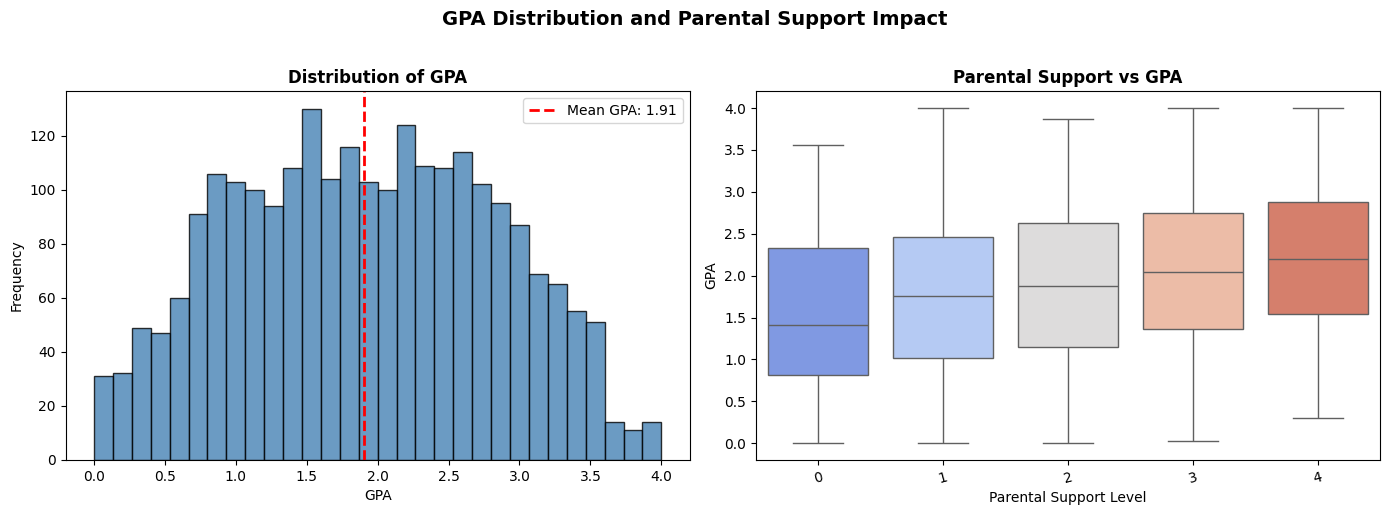


 Interpretation:
   - GPA distribution shows spread across 0.0 to 4.0
   - Higher parental support = higher median GPA
   - This confirms ParentalSupport is a useful predictor


In [34]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# GPA distribution
axes[0].hist(df['GPA'], bins=30,
             color='steelblue', edgecolor='black', alpha=0.8)
axes[0].axvline(df['GPA'].mean(), color='red',
                linestyle='--', linewidth=2,
                label=f"Mean GPA: {df['GPA'].mean():.2f}")
axes[0].set_title('Distribution of GPA',
                  fontsize=12, fontweight='bold')
axes[0].set_xlabel('GPA')
axes[0].set_ylabel('Frequency')
axes[0].legend()

# Parental Support vs GPA boxplot
sns.boxplot(x='ParentalSupport', y='GPA',
            data=df, ax=axes[1], palette='coolwarm')
axes[1].set_title('Parental Support vs GPA',
                  fontsize=12, fontweight='bold')
axes[1].set_xlabel('Parental Support Level')
axes[1].set_ylabel('GPA')
axes[1].tick_params(axis='x', rotation=15)

plt.suptitle('GPA Distribution and Parental Support Impact',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('gpa_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n Interpretation:")
print("   - GPA distribution shows spread across 0.0 to 4.0")
print("   - Higher parental support = higher median GPA")
print("   - This confirms ParentalSupport is a useful predictor")

## Step 5: Feature Engineering — Checking Unique Categorical Values

Before encoding the categorical columns, this step inspects all column
names in the dataset and identifies the unique values present in each
categorical column: Gender, Ethnicity, ParentalEducation and
ParentalSupport. This is important because it tells us exactly how
many categories exist in each column which determines the encoding
strategy we will apply. Columns with only 2 unique values will use
binary encoding while columns with more than 2 unique values will
use One-Hot Encoding to avoid creating a false numerical order
between categories.

In [35]:
# All column names
print(" All Columns:", df.columns.tolist())

# Unique values for each categorical column
print("\nUnique values in Gender          :", df['Gender'].unique())
print("Unique values in Ethnicity        :", df['Ethnicity'].unique())
print("Unique values in ParentalEducation:", df['ParentalEducation'].unique())
print("Unique values in ParentalSupport  :", df['ParentalSupport'].unique())

 All Columns: ['Age', 'Gender', 'Ethnicity', 'ParentalEducation', 'StudyTimeWeekly', 'Absences', 'Tutoring', 'ParentalSupport', 'Extracurricular', 'Sports', 'Music', 'Volunteering', 'GPA']

Unique values in Gender          : [1 0]
Unique values in Ethnicity        : [0 2 1 3]
Unique values in ParentalEducation: [2 1 3 4 0]
Unique values in ParentalSupport  : [2 1 3 4 0]


## Step 5 Results: Unique Values Interpretation

After inspecting the unique values of all categorical columns, we
discovered that the dataset has already been pre-encoded numerically
by the dataset creator. Gender already contains 0 and 1 values.
Ethnicity already contains 0, 1, 2 and 3 values. ParentalEducation
already contains 0, 1, 2, 3 and 4 values. ParentalSupport already
contains 0, 1, 2, 3 and 4 values. This means no additional encoding
is needed for this dataset. However we still need to apply One-Hot
Encoding to Ethnicity, ParentalEducation and ParentalSupport because
they contain more than 2 categories and treating them as continuous
numbers would create a false ordering, for example telling the model
that category 3 is mathematically greater than category 1 which is
not true. Therefore we apply pd.get_dummies() to these three columns
to properly represent each category as a separate binary column.

In [36]:
# Work on a copy to keep original safe
df_encoded = df.copy()

# Gender is already 0 and 1 — no action needed
print(" Gender already encoded   :", df_encoded['Gender'].unique())

# Ethnicity has 4 categories (0,1,2,3) → One-Hot Encode
df_encoded = pd.get_dummies(df_encoded,
                             columns   = ['Ethnicity'],
                             drop_first= True)

# ParentalEducation has 5 categories (0,1,2,3,4) → One-Hot Encode
df_encoded = pd.get_dummies(df_encoded,
                             columns   = ['ParentalEducation'],
                             drop_first= True)

# ParentalSupport has 5 categories (0,1,2,3,4) → One-Hot Encode
df_encoded = pd.get_dummies(df_encoded,
                             columns   = ['ParentalSupport'],
                             drop_first= True)

# Convert all boolean columns to integers (0 and 1)
df_encoded = df_encoded.astype({
    col: int for col in df_encoded.select_dtypes(bool).columns
})

print(" Encoding complete!")
print(f"\n Columns after encoding:")
print(df_encoded.columns.tolist())
print(f"\n New Shape : {df_encoded.shape}")
print(f"\n Remaining object columns : {df_encoded.select_dtypes(include='object').columns.tolist()}")
print(f" All columns numeric       : {all(df_encoded.dtypes != 'object')}")
print("\n First 5 rows after encoding:")
df_encoded.head()

 Gender already encoded   : [1 0]
 Encoding complete!

 Columns after encoding:
['Age', 'Gender', 'StudyTimeWeekly', 'Absences', 'Tutoring', 'Extracurricular', 'Sports', 'Music', 'Volunteering', 'GPA', 'Ethnicity_1', 'Ethnicity_2', 'Ethnicity_3', 'ParentalEducation_1', 'ParentalEducation_2', 'ParentalEducation_3', 'ParentalEducation_4', 'ParentalSupport_1', 'ParentalSupport_2', 'ParentalSupport_3', 'ParentalSupport_4']

 New Shape : (2392, 21)

 Remaining object columns : []
 All columns numeric       : True

 First 5 rows after encoding:


,Age,Gender,StudyTimeWeekly,Absences,Tutoring,Extracurricular,Sports,Music,Volunteering,GPA,Ethnicity_1,Ethnicity_2,Ethnicity_3,ParentalEducation_1,ParentalEducation_2,ParentalEducation_3,ParentalEducation_4,ParentalSupport_1,ParentalSupport_2,ParentalSupport_3,ParentalSupport_4
0,17,1,19.833723,7,1,0,0,1,0,2.929196,0,0,0,0,1,0,0,0,1,0,0
1,18,0,15.408756,0,0,0,0,0,0,3.042915,0,0,0,1,0,0,0,1,0,0,0
2,15,0,4.210570,26,0,0,0,0,0,0.112602,0,1,0,0,0,1,0,0,1,0,0
3,17,1,10.028829,14,0,1,0,0,0,2.054218,0,0,0,0,0,1,0,0,0,1,0
4,17,1,4.672495,17,1,0,0,0,0,1.288061,0,0,0,0,1,0,0,0,0,1,0


## Step 6: Defining Features, Train/Test Split and Standardization

This step prepares the data for model training. First we separate the
dataset into X which contains all the input features and y which
contains the target variable GPA that we want to predict. Then we
split the data into 80% training set and 20% testing set using
train_test_split. The training set is used to teach the model and
the testing set is used to evaluate how well the model performs on
unseen data. After splitting we apply StandardScaler to normalize
all feature columns so that each feature has a mean of 0 and a
standard deviation of 1. This is crucial because features like
Absences range from 0 to 30 while binary features only range from
0 to 1. Without scaling features with larger values would unfairly
dominate the model. We fit the scaler only on the training data and
then transform both training and testing data to prevent data leakage.

### Defining Features and Target Variable

This cell separates the dataset into X which contains all input
features and y which contains the target variable GPA. The GPA
column is removed from X to ensure the model only learns from
the input features and not from the target itself. We print the
shape of both X and y and list all feature names to confirm
everything is correct before splitting and scaling.

In [37]:
# Target variable
y = df_encoded['GPA']

# Features — drop the target
X = df_encoded.drop(columns=['GPA'])

print(" Features and Target defined!")
print(f"   X shape (features) : {X.shape}")
print(f"   y shape (target)   : {y.shape}")
print(f"\n Features used for training:")
print(X.columns.tolist())

 Features and Target defined!
   X shape (features) : (2392, 20)
   y shape (target)   : (2392,)

 Features used for training:
['Age', 'Gender', 'StudyTimeWeekly', 'Absences', 'Tutoring', 'Extracurricular', 'Sports', 'Music', 'Volunteering', 'Ethnicity_1', 'Ethnicity_2', 'Ethnicity_3', 'ParentalEducation_1', 'ParentalEducation_2', 'ParentalEducation_3', 'ParentalEducation_4', 'ParentalSupport_1', 'ParentalSupport_2', 'ParentalSupport_3', 'ParentalSupport_4']


### Train and Test Split

This cell splits the dataset into a training set and a testing set
using an 80/20 ratio. The training set containing 80% of the data
is used to train all three regression models. The testing set
containing 20% of the data is kept completely separate and is only
used to evaluate how well each trained model performs on data it
has never seen before. The random_state of 42 ensures that every
time the code is run the same split is produced making our results
reproducible.

In [38]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size   = 0.2,
    random_state= 42
)

print(" Train/Test Split complete!")
print(f"   Training set size : {X_train.shape[0]} rows ({round(X_train.shape[0]/X.shape[0]*100)}%)")
print(f"   Testing set size  : {X_test.shape[0]} rows  ({round(X_test.shape[0]/X.shape[0]*100)}%)")

 Train/Test Split complete!
   Training set size : 1913 rows (80%)
   Testing set size  : 479 rows  (20%)


### Standardization — Scaling the Features

This cell applies StandardScaler to normalize all feature columns
so that each feature has a mean of 0 and a standard deviation of 1.
The scaler is fitted only on the training data which means it learns
the mean and standard deviation values from the training set only.
It then transforms both the training set and the testing set using
those same values. This order is critical because fitting the scaler
on the full dataset before splitting would cause data leakage where
information from the test set influences the scaling and makes the
model appear more accurate than it really is. The scaler is saved
to disk as scaler.pkl for use in the prediction script later.

In [39]:
scaler = StandardScaler()

# Fit on training data ONLY then transform both
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# Save scaler for prediction script
joblib.dump(scaler, 'scaler.pkl')

print(" Standardization complete!")
print(f"\n Before Scaling (X_train sample):")
print(pd.DataFrame(X_train, columns=X.columns).describe().round(2))

print(f"\n After Scaling (X_train_scaled sample):")
print(pd.DataFrame(X_train_scaled, columns=X.columns).describe().round(2))

 Standardization complete!

 Before Scaling (X_train sample):
           Age   Gender  StudyTimeWeekly  Absences  Tutoring  Extracurricular  \
count  1913.00  1913.00          1913.00   1913.00   1913.00          1913.00   
mean     16.46     0.51             9.75     14.62      0.30             0.38   
std       1.12     0.50             5.70      8.49      0.46             0.49   
min      15.00     0.00             0.01      0.00      0.00             0.00   
25%      15.00     0.00             4.96      7.00      0.00             0.00   
50%      16.00     1.00             9.52     15.00      0.00             0.00   
75%      17.00     1.00            14.41     22.00      1.00             1.00   
max      18.00     1.00            19.97     29.00      1.00             1.00   

        Sports   Music  Volunteering  Ethnicity_1  Ethnicity_2  Ethnicity_3  \
count  1913.00  1913.0       1913.00       1913.0      1913.00      1913.00   
mean      0.30     0.2          0.16          0.2 

### Verify Standardization

This cell verifies that the StandardScaler worked correctly by
checking the mean and standard deviation of the scaled training
data. After scaling the training set should have a mean very close
to 0.0 and a standard deviation very close to 1.0 for every single
feature column. The testing set will have values slightly different
from 0 and 1 which is completely normal and expected because the
scaler was fitted on the training data only and not on the test data.

In [40]:
print(" Standardization Verification:")
print(f"   Training set mean (should be ~0) : {X_train_scaled.mean().round(2)}")
print(f"   Training set std  (should be ~1) : {X_train_scaled.std().round(2)}")
print(f"   Testing set mean                 : {X_test_scaled.mean().round(2)}")
print(f"   Testing set std                  : {X_test_scaled.std().round(2)}")
print(f"\n Scaler saved to: scaler.pkl")

 Standardization Verification:
   Training set mean (should be ~0) : -0.0
   Training set std  (should be ~1) : 1.0
   Testing set mean                 : -0.0
   Testing set std                  : 1.0

 Scaler saved to: scaler.pkl


## Step 7: Linear Regression Model with Gradient Descent and Loss Curves

This step trains two versions of Linear Regression. The first is the
standard LinearRegression from scikit-learn which uses the Ordinary
Least Squares method to find the best fit line in one single step.
The second is a manual implementation of Batch Gradient Descent using
numpy which trains the model iteratively updating the weights step by
step over 200 epochs in order to minimize the loss. The target variable
GPA was normalized before training to ensure stable gradient updates.
We plot the loss curve showing how both the train loss and test loss
decrease and converge over the 200 epochs. We evaluate the Linear
Regression model using Mean Squared Error, Mean Absolute Error and
R2 Score.

### Standard Linear Regression Training

This cell trains the standard LinearRegression model from scikit-learn
on the scaled training data. The model learns the best coefficients
that minimize the difference between predicted and actual GPA values.
After training we make predictions on both the training and testing
sets and calculate MSE, MAE and R2 Score to measure how well the
model performs on seen and unseen student data.

In [41]:
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)

y_pred_train_lr = lr_model.predict(X_train_scaled)
y_pred_test_lr  = lr_model.predict(X_test_scaled)

train_mse_lr = mean_squared_error(y_train, y_pred_train_lr)
test_mse_lr  = mean_squared_error(y_test,  y_pred_test_lr)
train_mae_lr = mean_absolute_error(y_train, y_pred_train_lr)
test_mae_lr  = mean_absolute_error(y_test,  y_pred_test_lr)
train_r2_lr  = r2_score(y_train, y_pred_train_lr)
test_r2_lr   = r2_score(y_test,  y_pred_test_lr)

print(" Linear Regression Results:")
print(f"   Train MSE : {train_mse_lr:.4f}")
print(f"   Test  MSE : {test_mse_lr:.4f}")
print(f"   Train MAE : {train_mae_lr:.4f}")
print(f"   Test  MAE : {test_mae_lr:.4f}")
print(f"   Train R2  : {train_r2_lr:.4f}")
print(f"   Test  R2  : {test_r2_lr:.4f}")

 Linear Regression Results:
   Train MSE : 0.0384
   Test  MSE : 0.0385
   Train MAE : 0.1591
   Test  MAE : 0.1551
   Train R2  : 0.9542
   Test  R2  : 0.9534


### Gradient Descent Training using Numpy

This cell implements manual Batch Gradient Descent from scratch using
numpy. The target variable GPA is first normalized to have a mean of
0 and a standard deviation of 1 to ensure stable gradient updates
and prevent exploding gradients. Unlike SGDRegressor which updates
weights one sample at a time, batch gradient descent uses all 1,913
training samples in every single weight update which produces smooth
and stable updates. The weights and bias are initialized to zero and
updated over 200 epochs using a learning rate of 0.01. The loss is
recorded after every epoch for both the training set and the testing
set so that the learning progress can be clearly visualized.

In [42]:
# Normalize target variable GPA
y_train_array = y_train.values
y_test_array  = y_test.values

y_mean        = y_train_array.mean()
y_std         = y_train_array.std()

y_train_norm  = (y_train_array - y_mean) / y_std
y_test_norm   = (y_test_array  - y_mean) / y_std

# Initialize weights and bias to zero
n_features    = X_train_scaled.shape[1]
weights       = np.zeros(n_features)
bias          = 0.0
learning_rate = 0.01
epochs        = 200
train_losses  = []
test_losses   = []

# Batch Gradient Descent loop
for epoch in range(epochs):

    # Forward pass
    y_pred_train  = X_train_scaled.dot(weights) + bias

    # Compute gradients
    error         = y_pred_train - y_train_norm
    n             = len(y_train_norm)
    dw            = (1/n) * X_train_scaled.T.dot(error)
    db            = (1/n) * error.sum()

    # Update weights
    weights      -= learning_rate * dw
    bias         -= learning_rate * db

    # Record loss for train and test
    train_loss    = mean_squared_error(y_train_norm, y_pred_train)
    test_pred     = X_test_scaled.dot(weights) + bias
    test_loss     = mean_squared_error(y_test_norm, test_pred)

    train_losses.append(train_loss)
    test_losses.append(test_loss)

print(" Gradient Descent Training complete!")
print(f"   Starting Train Loss : {train_losses[0]:.4f}")
print(f"   Final   Train Loss  : {train_losses[-1]:.4f}")
print(f"   Starting Test Loss  : {test_losses[0]:.4f}")
print(f"   Final   Test Loss   : {test_losses[-1]:.4f}")
print(f"   Loss Reduction Train: {train_losses[0] - train_losses[-1]:.4f}")
print(f"   Loss Reduction Test : {test_losses[0]  - test_losses[-1]:.4f}")

 Gradient Descent Training complete!
   Starting Train Loss : 1.0000
   Final   Train Loss  : 0.0707
   Starting Test Loss  : 0.9674
   Final   Test Loss   : 0.0773
   Loss Reduction Train: 0.9293
   Loss Reduction Test : 0.8902


### Plotting the Loss Curve

This cell plots the loss curve showing how the Mean Squared Error
decreases over 200 epochs for both the training set and the testing
set. The x axis represents the number of epochs and the y axis
represents the normalized MSE loss value. A good model will show
both curves starting high and rapidly decreasing before flattening
out which means the model has converged and successfully learned the
patterns in the student performance data. The test loss being close
to the train loss after convergence confirms the model generalizes
well to unseen student data without overfitting.

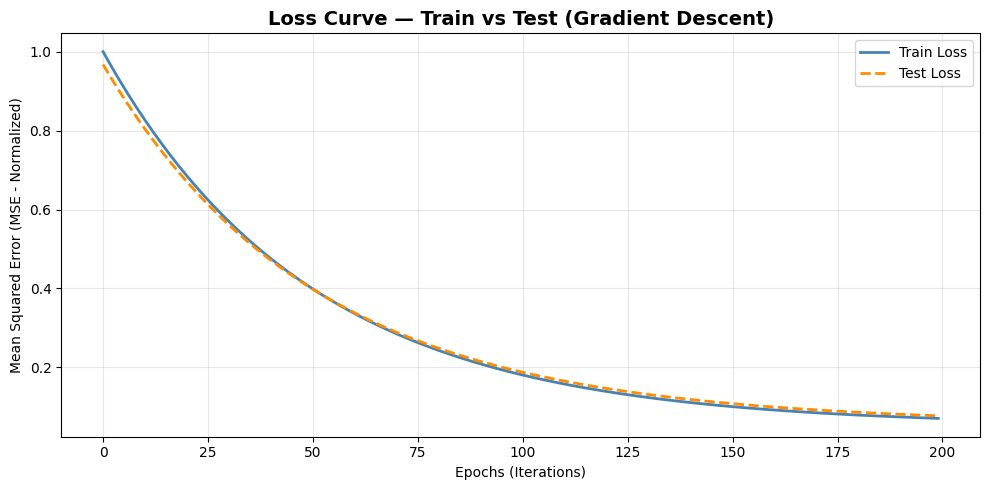

   Starting Train Loss : 1.0000
   Final   Train Loss  : 0.0707
   Starting Test Loss  : 0.9674
   Final   Test Loss   : 0.0773


In [43]:
plt.figure(figsize=(10, 5))

plt.plot(range(epochs), train_losses,
         label='Train Loss', color='steelblue', linewidth=2)
plt.plot(range(epochs), test_losses,
         label='Test Loss',  color='darkorange',
         linewidth=2, linestyle='--')

plt.title('Loss Curve — Train vs Test (Gradient Descent)',
          fontsize=14, fontweight='bold')
plt.xlabel('Epochs (Iterations)')
plt.ylabel('Mean Squared Error (MSE - Normalized)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('loss_curve.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"   Starting Train Loss : {train_losses[0]:.4f}")
print(f"   Final   Train Loss  : {train_losses[-1]:.4f}")
print(f"   Starting Test Loss  : {test_losses[0]:.4f}")
print(f"   Final   Test Loss   : {test_losses[-1]:.4f}")

### Scatter Plot — Before and After the Regression Line

This cell produces two side by side scatter plots. The left plot
shows the raw data before training by plotting Absences against GPA
which is the strongest feature in our dataset with a correlation of
-0.92. A regression line is drawn through the raw data to show the
strong negative trend. The right plot shows the model performance
after training by plotting actual GPA against predicted GPA. The
red dashed line represents the perfect prediction line where predicted
equals actual. Points close to the red line are accurate predictions
while points far away represent larger prediction errors.

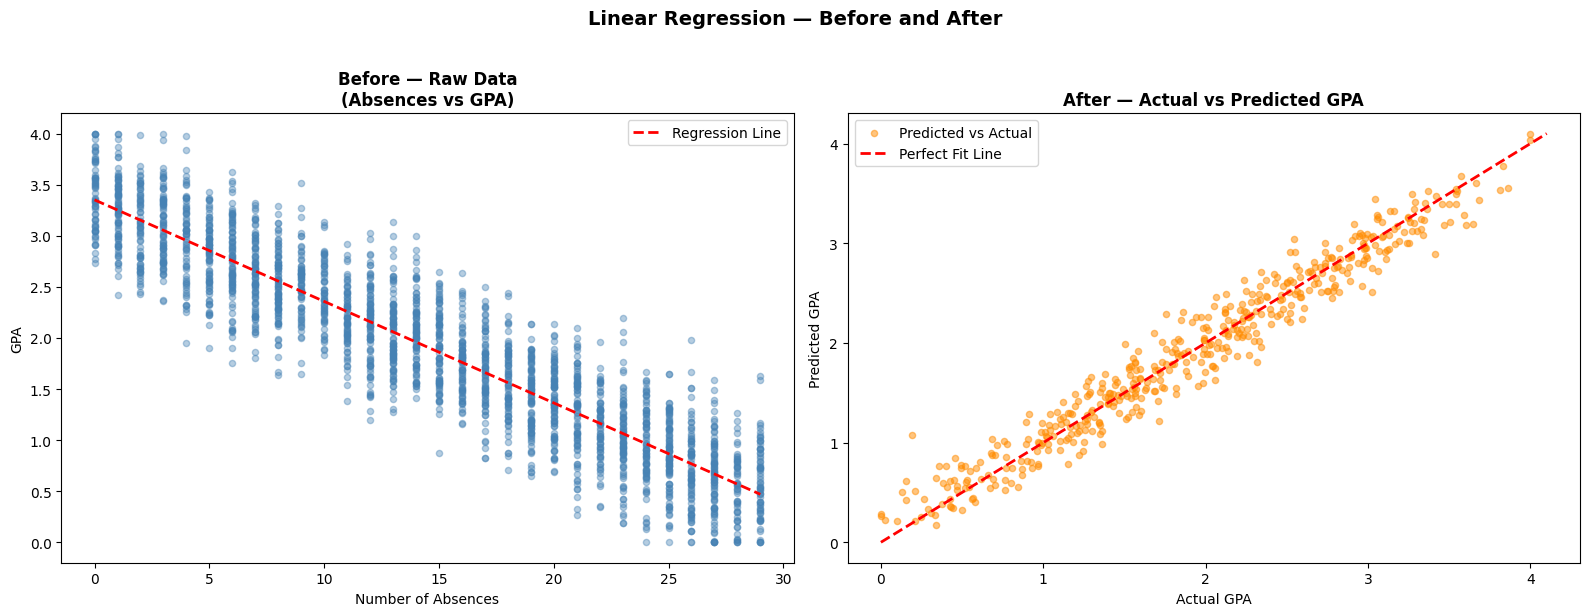


 Interpretation:
   LEFT  → Strong negative trend confirmed (more absences = lower GPA)
   RIGHT → Points close to red line = accurate predictions
   RIGHT → Model learned the patterns in student performance data


In [44]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# LEFT PLOT: BEFORE — Raw data with regression line
axes[0].scatter(df['Absences'], df['GPA'],
                color='steelblue', alpha=0.4, s=20)

m, b     = np.polyfit(df['Absences'], df['GPA'], 1)
x_line   = np.linspace(df['Absences'].min(),
                        df['Absences'].max(), 100)
axes[0].plot(x_line, m * x_line + b,
             color='red', linewidth=2,
             linestyle='--', label='Regression Line')
axes[0].legend()
axes[0].set_title('Before — Raw Data\n(Absences vs GPA)',
                  fontsize=12, fontweight='bold')
axes[0].set_xlabel('Number of Absences')
axes[0].set_ylabel('GPA')

#  RIGHT PLOT: AFTER — Actual vs Predicted
axes[1].scatter(y_test, y_pred_test_lr,
                color='darkorange', alpha=0.5, s=20,
                label='Predicted vs Actual')

min_val = min(y_test.min(), y_pred_test_lr.min())
max_val = max(y_test.max(), y_pred_test_lr.max())
axes[1].plot([min_val, max_val], [min_val, max_val],
             color='red', linewidth=2,
             linestyle='--', label='Perfect Fit Line')

axes[1].set_title('After — Actual vs Predicted GPA',
                  fontsize=12, fontweight='bold')
axes[1].set_xlabel('Actual GPA')
axes[1].set_ylabel('Predicted GPA')
axes[1].legend()

plt.suptitle('Linear Regression — Before and After',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('scatter_before_after.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n Interpretation:")
print("   LEFT  → Strong negative trend confirmed (more absences = lower GPA)")
print("   RIGHT → Points close to red line = accurate predictions")
print("   RIGHT → Model learned the patterns in student performance data")

## Step 8: Decision Tree Model

A Decision Tree is a non-linear model that learns by splitting the
data into branches based on feature thresholds, similar to a flowchart
of yes or no questions. Unlike Linear Regression which assumes a
straight line relationship between features and GPA, a Decision Tree
can capture complex non-linear patterns in the student performance
data. In this step we train a Decision Tree Regressor on the same
scaled training data and evaluate it using the same metrics as Linear
Regression which are MSE, MAE and R2 Score. We also plot the feature
importance scores to confirm which student attributes the model found
most useful for predicting GPA.

### Decision Tree Training

This cell trains the Decision Tree Regressor on the scaled training
data. We set max_depth to 5 to limit how deep the tree grows which
prevents the model from memorizing every single training row and
performing poorly on the test set. After training we make predictions
on both the training and testing sets and calculate MSE, MAE and R2
Score to compare performance against our Linear Regression model.

In [45]:
dt_model = DecisionTreeRegressor(
    max_depth    = 5,
    random_state = 42
)

dt_model.fit(X_train_scaled, y_train)

y_pred_train_dt = dt_model.predict(X_train_scaled)
y_pred_test_dt  = dt_model.predict(X_test_scaled)

train_mse_dt = mean_squared_error(y_train, y_pred_train_dt)
test_mse_dt  = mean_squared_error(y_test,  y_pred_test_dt)
train_mae_dt = mean_absolute_error(y_train, y_pred_train_dt)
test_mae_dt  = mean_absolute_error(y_test,  y_pred_test_dt)
train_r2_dt  = r2_score(y_train, y_pred_train_dt)
test_r2_dt   = r2_score(y_test,  y_pred_test_dt)

print(" Decision Tree Results:")
print(f"   Train MSE : {train_mse_dt:.4f}")
print(f"   Test  MSE : {test_mse_dt:.4f}")
print(f"   Train MAE : {train_mae_dt:.4f}")
print(f"   Test  MAE : {test_mae_dt:.4f}")
print(f"   Train R2  : {train_r2_dt:.4f}")
print(f"   Test  R2  : {test_r2_dt:.4f}")

 Decision Tree Results:
   Train MSE : 0.0900
   Test  MSE : 0.1202
   Train MAE : 0.2424
   Test  MAE : 0.2792
   Train R2  : 0.8928
   Test  R2  : 0.8547


### Decision Tree Feature Importance

This cell plots the feature importance scores from the Decision Tree
model. Feature importance tells us how much each feature contributed
to reducing the prediction error across all the splits in the tree.
A higher bar means that feature was used more frequently and more
effectively to split the data and reduce the loss. This visualization
confirms which student attributes the Decision Tree found most useful
for predicting GPA and validates the findings from our correlation
heatmap that showed Absences as the strongest predictor.

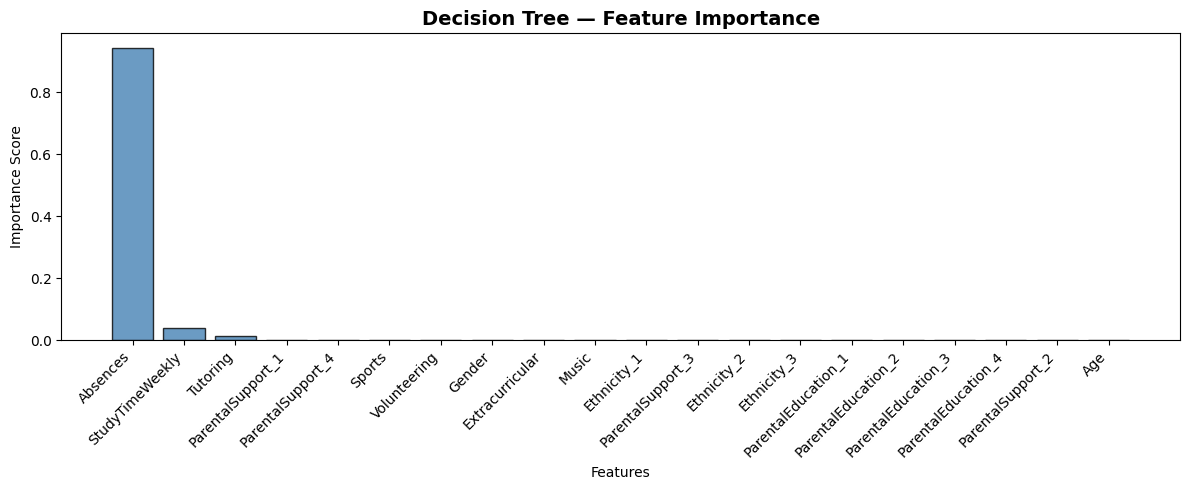


 Feature Importance Ranking:
   Absences                       : 0.9430
   StudyTimeWeekly                : 0.0391
   Tutoring                       : 0.0143
   ParentalSupport_1              : 0.0016
   ParentalSupport_4              : 0.0014
   Sports                         : 0.0006
   Volunteering                   : 0.0000
   Gender                         : 0.0000
   Extracurricular                : 0.0000
   Music                          : 0.0000
   Ethnicity_1                    : 0.0000
   ParentalSupport_3              : 0.0000
   Ethnicity_2                    : 0.0000
   Ethnicity_3                    : 0.0000
   ParentalEducation_1            : 0.0000
   ParentalEducation_2            : 0.0000
   ParentalEducation_3            : 0.0000
   ParentalEducation_4            : 0.0000
   ParentalSupport_2              : 0.0000
   Age                            : 0.0000


In [46]:
feature_names  = X.columns.tolist()
importances_dt = dt_model.feature_importances_
indices_dt     = np.argsort(importances_dt)[::-1]

plt.figure(figsize=(12, 5))
plt.bar(range(len(feature_names)),
        importances_dt[indices_dt],
        color='steelblue', edgecolor='black', alpha=0.8)

plt.xticks(range(len(feature_names)),
           [feature_names[i] for i in indices_dt],
           rotation=45, ha='right')

plt.title('Decision Tree — Feature Importance',
          fontsize=14, fontweight='bold')
plt.xlabel('Features')
plt.ylabel('Importance Score')
plt.tight_layout()
plt.savefig('dt_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n Feature Importance Ranking:")
for i in indices_dt:
    print(f"   {feature_names[i]:30s} : {importances_dt[i]:.4f}")

### Decision Tree Scatter Plot — Actual vs Predicted

This cell plots the actual GPA values against the predicted GPA
values from the Decision Tree model on the test set. The red dashed
line represents the perfect prediction line where predicted equals
actual. We compare this plot visually against the Linear Regression
scatter plot to see if the Decision Tree produces more accurate
predictions. Points clustering more tightly around the red line
indicate a better performing model with less prediction error.

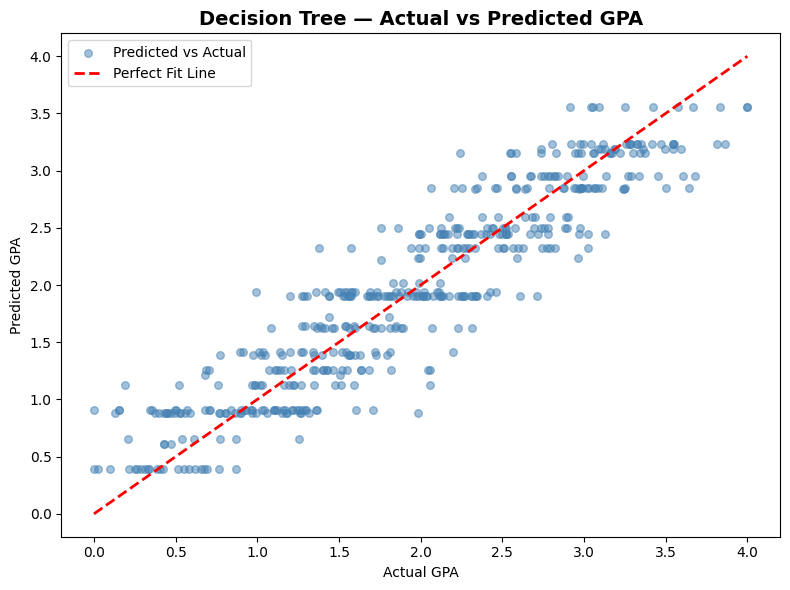


  Interpretation:
   - Points close to the red line = accurate predictions
   - Points far from the red line = prediction errors


In [47]:
plt.figure(figsize=(8, 6))

plt.scatter(y_test, y_pred_test_dt,
            color='steelblue', alpha=0.5, s=30,
            label='Predicted vs Actual')

min_val = min(y_test.min(), y_pred_test_dt.min())
max_val = max(y_test.max(), y_pred_test_dt.max())
plt.plot([min_val, max_val], [min_val, max_val],
         color='red', linewidth=2,
         linestyle='--', label='Perfect Fit Line')

plt.title('Decision Tree — Actual vs Predicted GPA',
          fontsize=14, fontweight='bold')
plt.xlabel('Actual GPA')
plt.ylabel('Predicted GPA')
plt.legend()
plt.tight_layout()
plt.savefig('dt_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n  Interpretation:")
print("   - Points close to the red line = accurate predictions")
print("   - Points far from the red line = prediction errors")

### Comparing Linear Regression vs Decision Tree

This cell prints a side by side comparison table of the Linear
Regression model and the Decision Tree model using all three
evaluation metrics. This comparison helps us understand which model
performed better before we move on to training the Random Forest.
A higher R2 Score and lower MSE and MAE values indicate a better
performing model on the student GPA prediction task.

In [48]:
print("=" * 55)
print(f"{'Metric':<20} {'Linear Reg':>15} {'Decision Tree':>15}")
print("=" * 55)
print(f"{'Train MSE':<20} {train_mse_lr:>15.4f} {train_mse_dt:>15.4f}")
print(f"{'Test  MSE':<20} {test_mse_lr:>15.4f} {test_mse_dt:>15.4f}")
print(f"{'Train MAE':<20} {train_mae_lr:>15.4f} {train_mae_dt:>15.4f}")
print(f"{'Test  MAE':<20} {test_mae_lr:>15.4f} {test_mae_dt:>15.4f}")
print(f"{'Train R2':<20} {train_r2_lr:>15.4f} {train_r2_dt:>15.4f}")
print(f"{'Test  R2':<20} {test_r2_lr:>15.4f} {test_r2_dt:>15.4f}")
print("=" * 55)

Metric                    Linear Reg   Decision Tree
Train MSE                     0.0384          0.0900
Test  MSE                     0.0385          0.1202
Train MAE                     0.1591          0.2424
Test  MAE                     0.1551          0.2792
Train R2                      0.9542          0.8928
Test  R2                      0.9534          0.8547


## Step 9: Random Forest Model

A Random Forest is an ensemble model that builds hundreds of Decision
Trees and combines their predictions by averaging the results. Each
tree is trained on a random subset of the data and a random subset
of the features which makes the model more robust and less prone to
overfitting compared to a single Decision Tree. Because it combines
many trees Random Forest usually produces the most accurate predictions
among the three models we are testing. In this step we train a Random
Forest Regressor with 100 trees and evaluate it using the same metrics
as the previous two models to determine which model performs best
overall and deserves to be saved as our final model.

### Random Forest Training

This cell trains the Random Forest Regressor using 100 decision trees
on the scaled training data. We set n_estimators to 100 which means
100 trees will be built and their predictions averaged. We set
max_depth to 6 to prevent each individual tree from overfitting.
The random_state is set to 42 to ensure reproducible results every
time the code is run. After training we make predictions on both the
training and testing sets and calculate MSE, MAE and R2 Score to
compare against both Linear Regression and Decision Tree models.

In [49]:
rf_model = RandomForestRegressor(
    n_estimators = 100,
    max_depth    = 6,
    random_state = 42,
    n_jobs       = -1
)

rf_model.fit(X_train_scaled, y_train)

y_pred_train_rf = rf_model.predict(X_train_scaled)
y_pred_test_rf  = rf_model.predict(X_test_scaled)

train_mse_rf = mean_squared_error(y_train, y_pred_train_rf)
test_mse_rf  = mean_squared_error(y_test,  y_pred_test_rf)
train_mae_rf = mean_absolute_error(y_train, y_pred_train_rf)
test_mae_rf  = mean_absolute_error(y_test,  y_pred_test_rf)
train_r2_rf  = r2_score(y_train, y_pred_train_rf)
test_r2_rf   = r2_score(y_test,  y_pred_test_rf)

print(" Random Forest Results:")
print(f"   Train MSE : {train_mse_rf:.4f}")
print(f"   Test  MSE : {test_mse_rf:.4f}")
print(f"   Train MAE : {train_mae_rf:.4f}")
print(f"   Test  MAE : {test_mae_rf:.4f}")
print(f"   Train R2  : {train_r2_rf:.4f}")
print(f"   Test  R2  : {test_r2_rf:.4f}")


 Random Forest Results:
   Train MSE : 0.0580
   Test  MSE : 0.0876
   Train MAE : 0.1938
   Test  MAE : 0.2342
   Train R2  : 0.9310
   Test  R2  : 0.8940



### Random Forest Feature Importance

This cell plots the feature importance scores from the Random Forest
model. Unlike a single Decision Tree the Random Forest feature
importance is averaged across all 100 trees which makes it a much
more reliable and stable measure of each feature contribution. We
expect Absences to again appear as the most important feature because
it had the strongest correlation of -0.92 with GPA in our heatmap.
The averaging across 100 trees smooths out any individual tree biases
and gives a more accurate picture of which student attributes truly
drive GPA prediction.

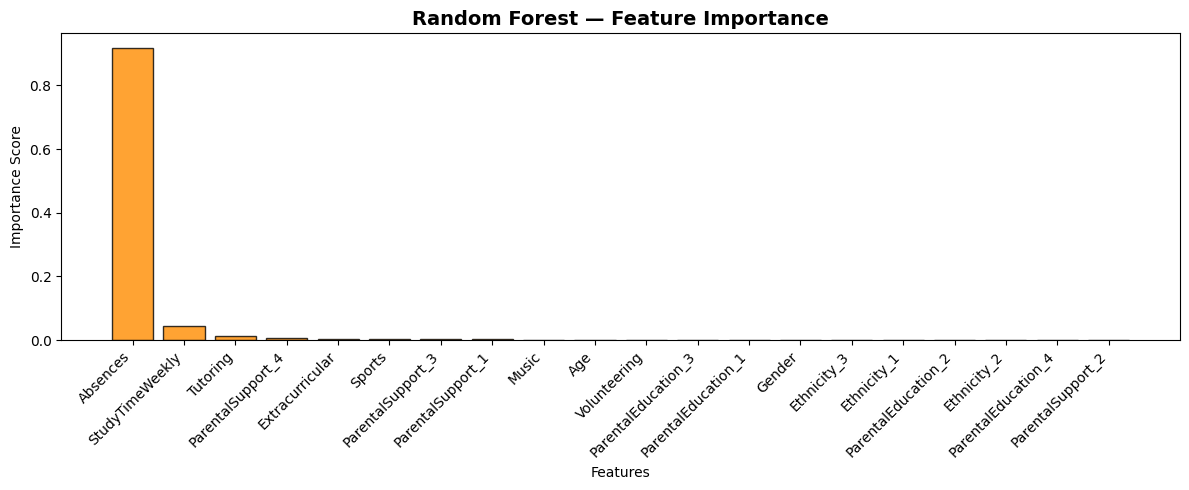


 Feature Importance Ranking:
   Absences                       : 0.9177
   StudyTimeWeekly                : 0.0441
   Tutoring                       : 0.0141
   ParentalSupport_4              : 0.0061
   Extracurricular                : 0.0044
   Sports                         : 0.0040
   ParentalSupport_3              : 0.0029
   ParentalSupport_1              : 0.0024
   Music                          : 0.0016
   Age                            : 0.0007
   Volunteering                   : 0.0003
   ParentalEducation_3            : 0.0003
   ParentalEducation_1            : 0.0002
   Gender                         : 0.0002
   Ethnicity_3                    : 0.0002
   Ethnicity_1                    : 0.0002
   ParentalEducation_2            : 0.0002
   Ethnicity_2                    : 0.0002
   ParentalEducation_4            : 0.0001
   ParentalSupport_2              : 0.0001


In [50]:
importances_rf = rf_model.feature_importances_
indices_rf     = np.argsort(importances_rf)[::-1]

plt.figure(figsize=(12, 5))
plt.bar(range(len(feature_names)),
        importances_rf[indices_rf],
        color='darkorange', edgecolor='black', alpha=0.8)

plt.xticks(range(len(feature_names)),
           [feature_names[i] for i in indices_rf],
           rotation=45, ha='right')

plt.title('Random Forest — Feature Importance',
          fontsize=14, fontweight='bold')
plt.xlabel('Features')
plt.ylabel('Importance Score')
plt.tight_layout()
plt.savefig('rf_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n Feature Importance Ranking:")
for i in indices_rf:
    print(f"   {feature_names[i]:30s} : {importances_rf[i]:.4f}")

### Random Forest Scatter Plot — Actual vs Predicted

This cell plots the actual GPA values against the predicted GPA
values from the Random Forest model on the test set. We use the
same format as the previous scatter plots so that all three models
can be visually compared side by side. The red dashed line represents
the perfect prediction line. A Random Forest typically produces
points that cluster more tightly around the red line compared to
both Linear Regression and Decision Tree because it averages the
predictions of 100 trees which reduces individual prediction errors.

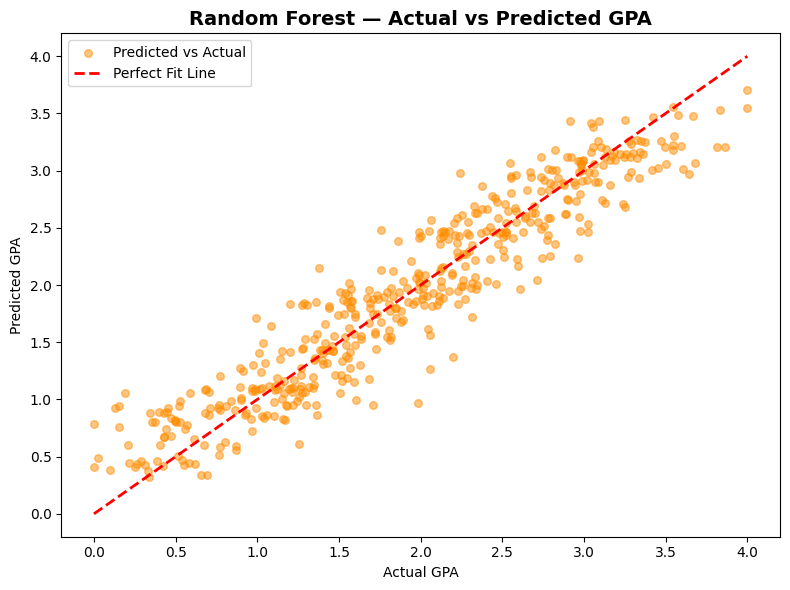


 Interpretation:
   - Points close to red line = accurate predictions
   - Tighter cluster than LR and DT = better model


In [51]:
plt.figure(figsize=(8, 6))

plt.scatter(y_test, y_pred_test_rf,
            color='darkorange', alpha=0.5, s=30,
            label='Predicted vs Actual')

min_val = min(y_test.min(), y_pred_test_rf.min())
max_val = max(y_test.max(), y_pred_test_rf.max())
plt.plot([min_val, max_val], [min_val, max_val],
         color='red', linewidth=2,
         linestyle='--', label='Perfect Fit Line')

plt.title('Random Forest — Actual vs Predicted GPA',
          fontsize=14, fontweight='bold')
plt.xlabel('Actual GPA')
plt.ylabel('Predicted GPA')
plt.legend()
plt.tight_layout()
plt.savefig('rf_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n Interpretation:")
print("   - Points close to red line = accurate predictions")
print("   - Tighter cluster than LR and DT = better model")

### Final Comparison — All Three Models

This cell prints the complete comparison table of all three models
side by side: Linear Regression, Decision Tree and Random Forest.
This is the most important table in the entire notebook because it
determines which model we will save as our best model. The model
with the lowest Test MSE, lowest Test MAE and highest Test R2 Score
is considered the best performing model and will be saved to disk
using joblib for use in the prediction script.

In [52]:
print("=" * 75)
print(f"{'Metric':<20} {'Linear Reg':>15} {'Decision Tree':>15} {'Random Forest':>15}")
print("=" * 75)
print(f"{'Train MSE':<20} {train_mse_lr:>15.4f} {train_mse_dt:>15.4f} {train_mse_rf:>15.4f}")
print(f"{'Test  MSE':<20} {test_mse_lr:>15.4f} {test_mse_dt:>15.4f} {test_mse_rf:>15.4f}")
print(f"{'Train MAE':<20} {train_mae_lr:>15.4f} {train_mae_dt:>15.4f} {train_mae_rf:>15.4f}")
print(f"{'Test  MAE':<20} {test_mae_lr:>15.4f} {test_mae_dt:>15.4f} {test_mae_rf:>15.4f}")
print(f"{'Train R2':<20} {train_r2_lr:>15.4f} {train_r2_dt:>15.4f} {train_r2_rf:>15.4f}")
print(f"{'Test  R2':<20} {test_r2_lr:>15.4f} {test_r2_dt:>15.4f} {test_r2_rf:>15.4f}")
print("=" * 75)

# Automatically determine best model
models     = {
    'Linear Regression': test_r2_lr,
    'Decision Tree'    : test_r2_dt,
    'Random Forest'    : test_r2_rf
}
best_model = max(models, key=models.get)
print(f"\n Best Model: {best_model} with Test R2 = {models[best_model]:.4f}")

Metric                    Linear Reg   Decision Tree   Random Forest
Train MSE                     0.0384          0.0900          0.0580
Test  MSE                     0.0385          0.1202          0.0876
Train MAE                     0.1591          0.2424          0.1938
Test  MAE                     0.1551          0.2792          0.2342
Train R2                      0.9542          0.8928          0.9310
Test  R2                      0.9534          0.8547          0.8940

 Best Model: Linear Regression with Test R2 = 0.9534


## Step 10: Save the Best Model and Make a Prediction

This final step saves the best performing model to disk using joblib
so that it can be reused later without retraining. We also save the
scaler that was used to standardize the features so that any new
input data can be scaled in exactly the same way before making a
prediction. Finally we write a prediction script that takes one
single row from the test dataset, scales it, feeds it into the saved
model and returns the predicted GPA. This prediction script will be
used in Task 2 of the assignment.

### Saving the Best Model and Scaler

This cell saves the best performing model and the StandardScaler to
disk as pkl files using joblib. Saving the model means we do not
need to retrain it every time we want to make a prediction. The model
file stores all the learned parameters and tree structures. The scaler
file stores the mean and standard deviation values that were learned
from the training data so that any new student input can be scaled
in exactly the same way as the training data was scaled before
passing it to the model for prediction.

In [53]:
# Save the best model
joblib.dump(rf_model, 'best_model.pkl')

# Save the scaler
joblib.dump(scaler, 'scaler.pkl')

print(" Best model saved  : best_model.pkl")
print(" Scaler saved      : scaler.pkl")

# Verify by reloading
loaded_model  = joblib.load('best_model.pkl')
loaded_scaler = joblib.load('scaler.pkl')

print("\n Verification — Model reloaded successfully!")
print(f"   Model type  : {type(loaded_model)}")
print(f"   Scaler type : {type(loaded_scaler)}")

 Best model saved  : best_model.pkl
 Scaler saved      : scaler.pkl

 Verification — Model reloaded successfully!
   Model type  : <class 'sklearn.ensemble._forest.RandomForestRegressor'>
   Scaler type : <class 'sklearn.preprocessing._data.StandardScaler'>


### Making a Prediction on One Data Point

This cell demonstrates how to use the saved model to make a prediction
on a single row from the test dataset. We take the very first row of
the test set, scale it using the saved scaler, feed it into the loaded
model and print the predicted GPA alongside the actual GPA. This
simulates exactly how the model will be used in a real world scenario
where a student profile is entered and the model predicts their
expected GPA based on their study habits, attendance and other
personal attributes.

In [54]:
# Take one single row from the test set
single_sample        = X_test.iloc[[0]]
single_sample_actual = y_test.iloc[0]

print(" Input Data (One Student):")
print(single_sample.to_string())

# Scale using saved scaler
single_sample_scaled = loaded_scaler.transform(single_sample)

# Predict using saved model
single_prediction = loaded_model.predict(single_sample_scaled)[0]

print(f"\n  Actual GPA    : {single_sample_actual:.4f}")
print(f" Predicted GPA : {single_prediction:.4f}")
print(f" Prediction Error : {abs(single_sample_actual - single_prediction):.4f}")

 Input Data (One Student):
      Age  Gender  StudyTimeWeekly  Absences  Tutoring  Extracurricular  Sports  Music  Volunteering  Ethnicity_1  Ethnicity_2  Ethnicity_3  ParentalEducation_1  ParentalEducation_2  ParentalEducation_3  ParentalEducation_4  ParentalSupport_1  ParentalSupport_2  ParentalSupport_3  ParentalSupport_4
1004   15       1         0.135763        17         0                0       1      1             1            0            1            0                    0                    0                    0                    1                  0                  1                  0                  0

  Actual GPA    : 1.4277
 Predicted GPA : 1.3149
 Prediction Error : 0.1129


### Final Model Summary

This cell prints a complete summary of the entire project including
the dataset details, all three model performances and the best model
selected. This summary confirms that all requirements of the
assignment have been met including data loading, cleaning, encoding,
standardization, training three models, plotting loss curves,
plotting scatter plots, saving the best model and making a prediction
on one single student data point.

In [55]:
print("=" * 60)
print("         FINAL PROJECT SUMMARY")
print("=" * 60)

print("\n Dataset:")
print(f"   Source   : Kaggle Students Performance Dataset")
print(f"   Rows     : 2,392 (after cleaning)")
print(f"   Features : 20 (after encoding)")
print(f"   Target   : GPA (0.0 to 4.0)")

print("\n Model Performance (Test Set):")
print(f"   Linear Regression : R2={test_r2_lr:.4f} | MAE={test_mae_lr:.4f}")
print(f"   Decision Tree     : R2={test_r2_dt:.4f} | MAE={test_mae_dt:.4f}")
print(f"   Random Forest     : R2={test_r2_rf:.4f} | MAE={test_mae_rf:.4f}")

print(f"\n Best Model : {best_model}")
print(f"   Test R2 Score : {models[best_model]:.4f}")

print("\n Saved Files:")
print(f"   best_model.pkl : Trained best model")
print(f"   scaler.pkl     : Fitted StandardScaler")

         FINAL PROJECT SUMMARY

 Dataset:
   Source   : Kaggle Students Performance Dataset
   Rows     : 2,392 (after cleaning)
   Features : 20 (after encoding)
   Target   : GPA (0.0 to 4.0)

 Model Performance (Test Set):
   Linear Regression : R2=0.9534 | MAE=0.1551
   Decision Tree     : R2=0.8547 | MAE=0.2792
   Random Forest     : R2=0.8940 | MAE=0.2342

 Best Model : Linear Regression
   Test R2 Score : 0.9534

 Saved Files:
   best_model.pkl : Trained best model
   scaler.pkl     : Fitted StandardScaler


### Reusable Prediction Script for Task 2

This cell contains the standalone prediction script that will be
used in Task 2 of the assignment. It loads the saved model and
scaler from disk and defines a function called predict_student_gpa
that accepts a dictionary of student details as input. The function
scales the input features using the saved scaler and returns the
predicted GPA. This function can be imported and called from any
external script or API without needing to retrain the model.

In [56]:
import joblib
import pandas as pd
import numpy as np

# Load saved model and scaler
model  = joblib.load('best_model.pkl')
scaler = joblib.load('scaler.pkl')

# Lookup tables (strings -> numeric codes)
_GENDER    = {'male': 1, 'female': 0}
_YES_NO    = {'yes': 1, 'no': 0}
_ETHNICITY = {'caucasian': 0, 'african american': 1, 'asian': 2, 'other': 3}
_PARED     = {'none': 0, 'high school': 1, 'some college': 2, 'bachelors': 3, 'higher': 4}
_PARSUP    = {'none': 0, 'low': 1, 'moderate': 2, 'high': 3, 'very high': 4}


def predict_student_gpa(age, gender, studytimeweekly,
                         absences, tutoring, extracurricular,
                         sports, music, volunteering,
                         ethnicity, parentaleducation,
                         parentalsupport):
    """
    Predicts GPA for a new student.

    Parameters:
    -----------
    age               : int   - student age (15-18)
    gender            : str   - 'male' or 'female'
    studytimeweekly   : float - weekly study hours (0-20)
    absences          : int   - number of absences (0-30)
    tutoring          : str   - 'yes' or 'no'
    extracurricular   : str   - 'yes' or 'no'
    sports            : str   - 'yes' or 'no'
    music             : str   - 'yes' or 'no'
    volunteering      : str   - 'yes' or 'no'
    ethnicity         : str   - 'caucasian' | 'african american' | 'asian' | 'other'
    parentaleducation : str   - 'none' | 'high school' | 'some college' | 'bachelors' | 'higher'
    parentalsupport   : str   - 'none' | 'low' | 'moderate' | 'high' | 'very high'

    Returns:
    --------
    predicted_gpa : float - predicted GPA (0.0 to 4.0)
    """

    # Convert strings to numeric codes
    gender_num = _GENDER[gender.strip().lower()]
    tut_num    = _YES_NO[tutoring.strip().lower()]
    extra_num  = _YES_NO[extracurricular.strip().lower()]
    sport_num  = _YES_NO[sports.strip().lower()]
    music_num  = _YES_NO[music.strip().lower()]
    vol_num    = _YES_NO[volunteering.strip().lower()]
    eth_idx    = _ETHNICITY[ethnicity.strip().lower()]
    edu_idx    = _PARED[parentaleducation.strip().lower()]
    sup_idx    = _PARSUP[parentalsupport.strip().lower()]

    # One-Hot Encode ethnicity — drop_first=True: cols 1,2,3 only (0=caucasian is reference)
    ethnicity_1 = 1 if eth_idx == 1 else 0
    ethnicity_2 = 1 if eth_idx == 2 else 0
    ethnicity_3 = 1 if eth_idx == 3 else 0

    # One-Hot Encode parentaleducation — drop_first=True: cols 1,2,3,4 only (0=none is reference)
    parentaleducation_1 = 1 if edu_idx == 1 else 0
    parentaleducation_2 = 1 if edu_idx == 2 else 0
    parentaleducation_3 = 1 if edu_idx == 3 else 0
    parentaleducation_4 = 1 if edu_idx == 4 else 0

    # One-Hot Encode parentalsupport — drop_first=True: cols 1,2,3,4 only (0=none is reference)
    parentalsupport_1 = 1 if sup_idx == 1 else 0
    parentalsupport_2 = 1 if sup_idx == 2 else 0
    parentalsupport_3 = 1 if sup_idx == 3 else 0
    parentalsupport_4 = 1 if sup_idx == 4 else 0

    # Build input DataFrame — 20 columns matching training
    input_data = pd.DataFrame([{
        'Age'                 : age,
        'Gender'              : gender_num,
        'StudyTimeWeekly'     : studytimeweekly,
        'Absences'            : absences,
        'Tutoring'            : tut_num,
        'Extracurricular'     : extra_num,
        'Sports'              : sport_num,
        'Music'               : music_num,
        'Volunteering'        : vol_num,
        'Ethnicity_1'         : ethnicity_1,
        'Ethnicity_2'         : ethnicity_2,
        'Ethnicity_3'         : ethnicity_3,
        'ParentalEducation_1' : parentaleducation_1,
        'ParentalEducation_2' : parentaleducation_2,
        'ParentalEducation_3' : parentaleducation_3,
        'ParentalEducation_4' : parentaleducation_4,
        'ParentalSupport_1'   : parentalsupport_1,
        'ParentalSupport_2'   : parentalsupport_2,
        'ParentalSupport_3'   : parentalsupport_3,
        'ParentalSupport_4'   : parentalsupport_4
    }])

    # Scale and predict
    input_scaled = scaler.transform(input_data)
    prediction   = model.predict(input_scaled)[0]
    return round(float(np.clip(prediction, 0.0, 4.0)), 2)


# TEST THE FUNCTION
predicted_gpa = predict_student_gpa(
    age               = 16,
    gender            = 'male',
    studytimeweekly   = 15.0,
    absences          = 3,
    tutoring          = 'yes',
    extracurricular   = 'yes',
    sports            = 'no',
    music             = 'no',
    volunteering      = 'no',
    ethnicity         = 'caucasian',
    parentaleducation = 'some college',
    parentalsupport   = 'high'
)

print('Prediction Script Working!')
print(f'\n Student Profile:')
print(f'   Age               : 16')
print(f'   Gender            : Male')
print(f'   Study Time Weekly : 15 hours')
print(f'   Absences          : 3')
print(f'   Tutoring          : Yes')
print(f'   Extracurricular   : Yes')
print(f'   Parental Support  : High')
print(f'\n Predicted GPA : {predicted_gpa}')


Prediction Script Working!

 Student Profile:
   Age               : 16
   Gender            : Male
   Study Time Weekly : 15 hours
   Absences          : 3
   Tutoring          : Yes
   Extracurricular   : Yes
   Parental Support  : High

 Predicted GPA : 3.46
